# Notebook 4: Exploratory Data Analysis

## Objective 
The objective of this notebook is to explore the feature-engineered dataset before model development. The analysis assesses the distibutions, temporal patterns, category-level differences, and relationships between exchange-rate movements and food price indicators. The exploratory analysis is intended to identify important patterns, potential anomalies, and relationships that may inform the subsequent econometric and machine learning modelling stages.

In [271]:
# import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [272]:
# load the dataset
data = pd.read_csv(
    "../data/processed/featured_data.csv",
    parse_dates=["Date"]
)

In [273]:
# view the data
data.head()

,Date,DivisionDescription,GroupDescription,ClassDescription,SubclassDescription,Weight,Eight digit code,CPI,ExchangeRate,Year,...,ExchangeRate_Lag1,ExchangeRate_Lag3,ExchangeRate_Lag6,CPI_Lag1,CPI_Lag3,ExchangeRate_Change,Depreciation,Appreciation,ExchangeRate_MA3,ExchangeRate_STD3
0,2015-07-01,Food and non-alcoholic beverages,Food,Cereal products,Cereals,0.540243,1111201,57.2,12.452687,2015,...,12.303048,12.012553,11.566500,57.0,57.0,0.012163,0.012163,0.000000,12.241892,0.247116
1,2015-08-01,Food and non-alcoholic beverages,Food,Cereal products,Cereals,0.540243,1111201,59.3,12.914595,2015,...,12.452687,11.969940,11.577440,57.2,57.3,0.037093,0.037093,0.000000,12.556777,0.318784
2,2015-09-01,Food and non-alcoholic beverages,Food,Cereal products,Cereals,0.540243,1111201,58.9,13.610852,2015,...,12.914595,12.303048,12.068727,59.3,57.0,0.053912,0.053912,0.000000,12.992711,0.583021
3,2015-10-01,Food and non-alcoholic beverages,Food,Cereal products,Cereals,0.540243,1111201,59.5,13.504323,2015,...,13.610852,12.452687,12.012553,58.9,57.2,-0.007827,0.000000,0.007827,13.343257,0.375034
4,2015-11-01,Food and non-alcoholic beverages,Food,Cereal products,Cereals,0.540243,1111201,58.9,14.125733,2015,...,13.504323,12.914595,11.969940,59.5,59.3,0.046016,0.046016,0.000000,13.746969,0.332316


In [274]:
# inspect data
print("Shape:", data.shape)

Shape: (14150, 22)


In [275]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 14150 entries, 0 to 14149
Data columns (total 22 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   Date                 14150 non-null  datetime64[us]
 1   DivisionDescription  14150 non-null  str           
 2   GroupDescription     14150 non-null  str           
 3   ClassDescription     14150 non-null  str           
 4   SubclassDescription  14150 non-null  str           
 5   Weight               14150 non-null  float64       
 6   Eight digit code     14150 non-null  int64         
 7   CPI                  14150 non-null  float64       
 8   ExchangeRate         14150 non-null  float64       
 9   Year                 14150 non-null  int64         
 10  Month                14150 non-null  int64         
 11  Quarter              14150 non-null  int64         
 12  ExchangeRate_Lag1    14150 non-null  float64       
 13  ExchangeRate_Lag3    14150 non-null  float

In [276]:
data.describe()

,Date,Weight,Eight digit code,CPI,ExchangeRate,Year,Month,Quarter,ExchangeRate_Lag1,ExchangeRate_Lag3,ExchangeRate_Lag6,CPI_Lag1,CPI_Lag3,ExchangeRate_Change,Depreciation,Appreciation,ExchangeRate_MA3,ExchangeRate_STD3
count,14150,14150.000000,1.415000e+04,14150.000000,14150.000000,14150.000000,14150.000000,14150.000000,14150.000000,14150.000000,14150.000000,14150.000000,14150.000000,14150.000000,14150.000000,14150.000000,14150.000000,14150.000000
mean,2020-12-05 13:01:46.346289,0.144390,1.160668e+06,80.513258,15.794418,2020.459293,6.653852,2.550883,15.760464,15.681964,15.547186,80.141845,79.395081,0.002929,0.014649,0.011720,15.758757,0.369359
min,2015-07-01 00:00:00,0.010375,1.111201e+06,40.100000,11.824600,2015.000000,1.000000,1.000000,11.824600,11.824600,11.566500,40.100000,40.100000,-0.074539,0.000000,0.000000,11.915853,0.053243
25%,2018-05-01 00:00:00,0.032154,1.124004e+06,68.100000,14.091309,2018.000000,4.000000,2.000000,14.081841,14.047787,13.923768,67.700000,67.200000,-0.019830,0.000000,0.000000,14.113855,0.200526
50%,2021-01-01 00:00:00,0.089114,1.161201e+06,78.700000,15.215175,2021.000000,7.000000,3.000000,15.146414,15.062438,14.984636,78.200000,77.500000,-0.004332,0.000000,0.004332,15.231720,0.315739
75%,2023-08-01 00:00:00,0.173193,1.186001e+06,95.300000,17.836520,2023.000000,10.000000,4.000000,17.836520,17.836520,17.836520,94.900000,93.900000,0.022168,0.022168,0.019830,17.751849,0.473305
max,2025-12-01 00:00:00,1.447038,1.290001e+06,172.100000,19.065941,2025.000000,12.000000,4.000000,19.065941,19.065941,19.065941,172.100000,172.100000,0.115651,0.115651,0.074539,18.929468,1.784508
std,NaN,0.190869,3.739225e+04,15.720060,2.054620,3.021960,3.437996,1.113747,2.076117,2.117505,2.167035,15.699572,15.626240,0.033929,0.023775,0.015573,2.044655,0.247968


In [277]:
# missing values
missing_values = data.isna().sum()
missing_values[missing_values > 0]

Series([], dtype: int64)

In [278]:
# date coverage 
print("Start date:", data["Date"].min())
print("End date:", data["Date"].max())

Start date: 2015-07-01 00:00:00
End date: 2025-12-01 00:00:00


In [279]:
# check observations per year
observations_per_year = (
    data.groupby(data["Date"].dt.year)
    .size()
)

observations_per_year

Date
2015     570
2016    1140
2017    1293
2018    1344
2019    1344
2020    1344
2021    1344
2022    1389
2023    1404
2024    1404
2025    1574
dtype: int64

In [280]:
# check missing values
missing_values = data.isna().sum()
missing_values[missing_values > 0]

Series([], dtype: int64)

In [281]:
# duplicate observations
data.duplicated().sum()

np.int64(0)

In [282]:
data.duplicated(
    subset=["Date", "Eight digit code"]
).sum()

np.int64(0)

In [283]:
# food categories analysis
print("Number of food categories:", data["SubclassDescription"].nunique())

Number of food categories: 49


In [284]:
data["SubclassDescription"].unique()

<StringArray>
[                                                               'Cereals',
                                                       'Flour of cereals',
                                              'Bread and bakery products',
                                                      'Breakfast cereals',
                 'Macaroni, noodles, couscous and similar pasta products',
                                         'Meat, fresh, chilled or frozen',
                               'Meat , dried, salted, in brine or smoked',
                    'Offal, blood and other parts of slaughtered animals',
 'Meat, offal, blood and other parts of slaughtered animals preparations',
                                                                   'Fish',
                                                      'Fish preparations',
                                                          'Other seafood',
                                                                   'Milk',
           

In [285]:
category_counts = (
    data["SubclassDescription"]
    .value_counts()
)

category_counts.head(10)

SubclassDescription
Meat, fresh, chilled or frozen                                            1029
Bread and bakery products                                                  840
Salt, condiments and sauces                                                756
Meat, offal, blood and other parts of slaughtered animals preparations     523
Cheese                                                                     514
Other vegetables, fresh or chilled                                         514
Milk                                                                       504
Fruit-bearing vegetables, fresh or chilled                                 504
Other food products n.e.c.                                                 504
Meat , dried, salted, in brine or smoked                                   378
Name: count, dtype: int64

In [286]:
# EDA Question 1: How did the exchange rate behave during the study period?

monthly_exchange = (
    data[["Date", "ExchangeRate"]]
    .drop_duplicates()
    .sort_values("Date")
)

monthly_exchange.head()

,Date,ExchangeRate
0,2015-07-01,12.452687
1,2015-08-01,12.914595
2,2015-09-01,13.610852
3,2015-10-01,13.504323
4,2015-11-01,14.125733


In [287]:
monthly_exchange.shape

(126, 2)

In [288]:
monthly_exchange["Date"].min(), monthly_exchange["Date"].max()

(Timestamp('2015-07-01 00:00:00'), Timestamp('2025-12-01 00:00:00'))

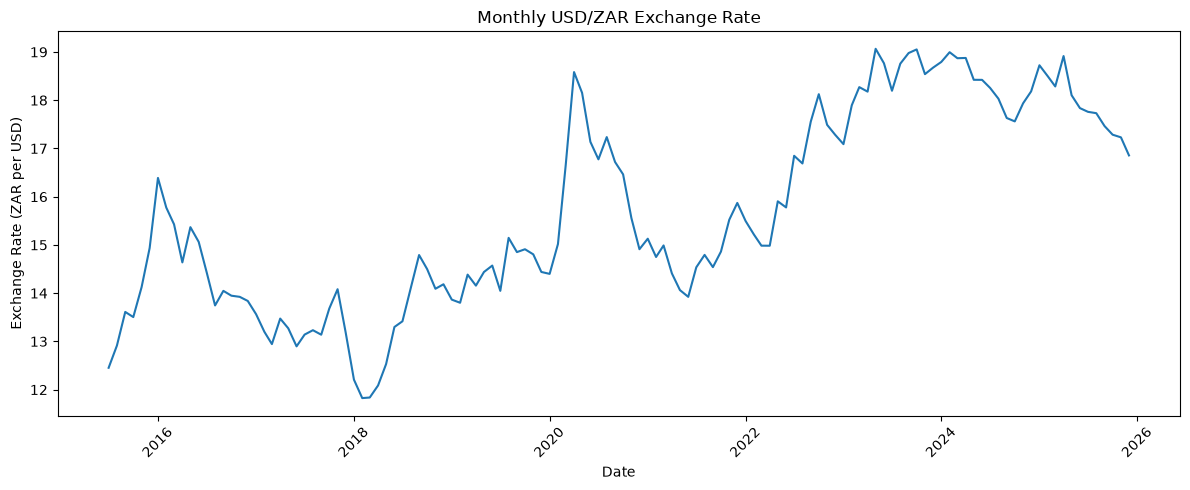

In [289]:
plt.figure(figsize=(12,5))

plt.plot(
    monthly_exchange["Date"],
    monthly_exchange["ExchangeRate"]
)
plt.title("Monthly USD/ZAR Exchange Rate")
plt.xlabel("Date")
plt.ylabel("Exchange Rate (ZAR per USD)")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

### Visual and Calculation analysis

The USD/ZAR exchange rate displays substantial fluctuations throughout the study period rather than following a consistently increasing or decreasing trend. The highest observed exchange rate in the feature-engineered dataset occurred in May 2023 at R19.065941 per USD, while the lowest occurred in February 2018 at R11.8246 per USD.

The difference between these values indicates considerable variation in the Rand's value relative to the US Dollar during the study period. Several additional periods of exchange-rate movement are visible in the time-series plot and may need further investigation when interpreting exchange-rate pass-through to food prices.

In [290]:
# calculations
print("Exact date and exchange rate value at maximum:\n",
      monthly_exchange.loc[
     monthly_exchange["ExchangeRate"].idxmax()
])

Exact date and exchange rate value at maximum:
 Date            2023-05-01 00:00:00
ExchangeRate              19.065941
Name: 94, dtype: object


In [291]:
print("Exact date and exchange rate value at minimum:\n",
      monthly_exchange.loc[
          monthly_exchange["ExchangeRate"].idxmin()
      ]
      )

Exact date and exchange rate value at minimum:
 Date            2018-02-01 00:00:00
ExchangeRate                11.8246
Name: 31, dtype: object


In [292]:
#  EDA Question 2: How have food prices changed over the same period?

food_cpi_monthly = (
    data.groupby("Date")["CPI"]
    .mean()
    .reset_index()
)

In [293]:
food_cpi_monthly.head()

,Date,CPI
0,2015-07-01,57.486316
1,2015-08-01,58.254737
2,2015-09-01,58.181053
3,2015-10-01,58.580000
4,2015-11-01,58.867368


In [294]:
food_cpi_monthly.head()

,Date,CPI
0,2015-07-01,57.486316
1,2015-08-01,58.254737
2,2015-09-01,58.181053
3,2015-10-01,58.580000
4,2015-11-01,58.867368


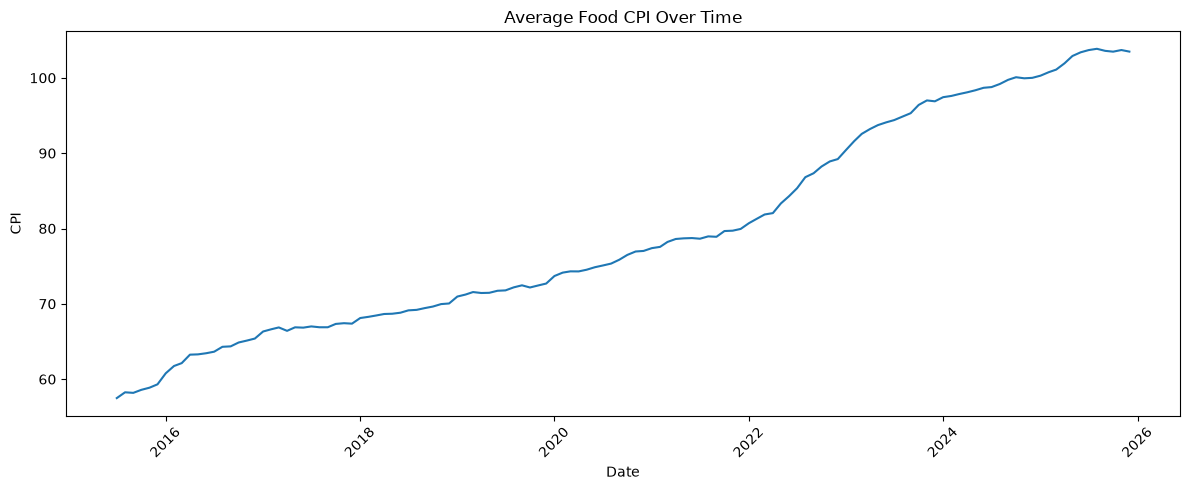

In [295]:
plt.figure(figsize=(12,5))

plt.plot(
    food_cpi_monthly["Date"],
    food_cpi_monthly["CPI"]
)

plt.title("Average Food CPI Over Time")
plt.xlabel("Date")
plt.ylabel("CPI")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [296]:
# cpi investigation
data[["Date", "SubclassDescription", "CPI"]].head(10)

,Date,SubclassDescription,CPI
0,2015-07-01,Cereals,57.2
1,2015-08-01,Cereals,59.3
2,2015-09-01,Cereals,58.9
3,2015-10-01,Cereals,59.5
4,2015-11-01,Cereals,58.9
5,2015-12-01,Cereals,58.7
6,2016-01-01,Cereals,59.7
7,2016-02-01,Cereals,59.9
8,2016-03-01,Cereals,60.2
9,2016-04-01,Cereals,61.3


In [297]:
category_cpi = (
    data.groupby("SubclassDescription")["CPI"]
    .agg(["mean", "min", "max"])
    .sort_values("mean", ascending=False)
)

category_cpi.head(10)

,mean,min,max
SubclassDescription,,,
Other seafood,107.140000,105.7,108.6
Butter and other fats and oils derived from milk,102.060000,99.2,104.4
"Jams, fruit jellies, marmelades, fruit puree and paste",96.801818,80.7,106.9
"Other fruits, fresh",91.046825,73.6,120.7
"Spices, culinary herbs and seeds",89.483969,57.6,107.2
"Meat, fresh, chilled or frozen",85.935374,56.8,129.4
"Meat, offal, blood and other parts of slaughtered animals preparations",85.813958,60.3,119.4
Baby food,85.813725,61.1,106.3
Flour of cereals,85.346307,56.3,113.1


In [298]:
category_cpi.sort_values("mean").head(10)

,mean,min,max
SubclassDescription,,,
"Dates, figs and tropical fruits, fresh",69.493651,40.1,100.0
Pulses,71.129365,46.4,101.5
Eggs,71.962698,48.8,104.4
"Chocolate, cocoa, and cocoa-based food products",72.133730,45.3,107.5
Tubers,72.451984,44.8,114.9
Sugar,72.855159,42.6,103.7
Other milk and cream,74.540873,48.3,104.9
Water,75.089683,55.1,102.6
"Nut puree, nut butter and nut pastes",75.150000,50.9,101.2


In [299]:
category_cpi.sort_values("mean", ascending=False).head(10)

,mean,min,max
SubclassDescription,,,
Other seafood,107.140000,105.7,108.6
Butter and other fats and oils derived from milk,102.060000,99.2,104.4
"Jams, fruit jellies, marmelades, fruit puree and paste",96.801818,80.7,106.9
"Other fruits, fresh",91.046825,73.6,120.7
"Spices, culinary herbs and seeds",89.483969,57.6,107.2
"Meat, fresh, chilled or frozen",85.935374,56.8,129.4
"Meat, offal, blood and other parts of slaughtered animals preparations",85.813958,60.3,119.4
Baby food,85.813725,61.1,106.3
Flour of cereals,85.346307,56.3,113.1


In [300]:
data["CPI_Change"] = (
    data.groupby("Eight digit code")["CPI"]
    .pct_change()
)

In [301]:
data[["Date", "SubclassDescription", "CPI", "CPI_Change"]].head(15)

,Date,SubclassDescription,CPI,CPI_Change
0,2015-07-01,Cereals,57.2,NaN
1,2015-08-01,Cereals,59.3,0.036713
2,2015-09-01,Cereals,58.9,-0.006745
3,2015-10-01,Cereals,59.5,0.010187
4,2015-11-01,Cereals,58.9,-0.010084
5,2015-12-01,Cereals,58.7,-0.003396
6,2016-01-01,Cereals,59.7,0.017036
7,2016-02-01,Cereals,59.9,0.003350
8,2016-03-01,Cereals,60.2,0.005008
9,2016-04-01,Cereals,61.3,0.018272


In [302]:
data["CPI_Change_Pct"] = data["CPI_Change"] * 100

In [303]:
data[[
    "Date",
    "SubclassDescription",
    "CPI",
    "CPI_Change_Pct"
]].head(15)

,Date,SubclassDescription,CPI,CPI_Change_Pct
0,2015-07-01,Cereals,57.2,NaN
1,2015-08-01,Cereals,59.3,3.671329
2,2015-09-01,Cereals,58.9,-0.674536
3,2015-10-01,Cereals,59.5,1.018676
4,2015-11-01,Cereals,58.9,-1.008403
5,2015-12-01,Cereals,58.7,-0.339559
6,2016-01-01,Cereals,59.7,1.703578
7,2016-02-01,Cereals,59.9,0.335008
8,2016-03-01,Cereals,60.2,0.500835
9,2016-04-01,Cereals,61.3,1.827243


In [304]:
# inspect CPI changes
data["CPI_Change_Pct"].describe()

count    14016.000000
mean         0.505561
std          2.465435
min        -20.660147
25%         -0.408267
50%          0.370828
75%          1.327581
max         32.545455
Name: CPI_Change_Pct, dtype: float64

### CPI Analysis

The average monthly CPI change is approximately 0.51%, while the median is 0.37%. This means that the CPI generally increased from one month to the next across the category-month observations.


CPI: Consumer Price index, measures monthly changes in prices for a range of consumer product.

In [305]:
# extreme observations
data.loc[
    data["CPI_Change_Pct"].idxmin(),
    ["Date", "SubclassDescription", "CPI", "CPI_Change_Pct"]
]

Date                                          2015-10-01 00:00:00
SubclassDescription    Fruit-bearing vegetables, fresh or chilled
CPI                                                          64.9
CPI_Change_Pct                                         -20.660147
Name: 8140, dtype: object

In [306]:
data.loc[
    data["CPI_Change_Pct"].idxmax(),
    ["Date", "SubclassDescription", "CPI", "CPI_Change_Pct"]
]

Date                                          2016-12-01 00:00:00
SubclassDescription    Leafy or stem vegetables, fresh or chilled
CPI                                                          72.9
CPI_Change_Pct                                          32.545455
Name: 7776, dtype: object

In [307]:
# negative extreme 
data[
    (data["SubclassDescription"] == "Fruit-bearing vegetables, fresh or chilled") &
    (data["Date"].between("2015-08-01", "2015-10-01"))
][[
    "Date",
    "SubclassDescription",
    "CPI",
    "CPI_Change_Pct"
]]

,Date,SubclassDescription,CPI,CPI_Change_Pct
8012,2015-08-01,"Fruit-bearing vegetables, fresh or chilled",54.2,3.041825
8013,2015-09-01,"Fruit-bearing vegetables, fresh or chilled",55.3,2.029520
8014,2015-10-01,"Fruit-bearing vegetables, fresh or chilled",61.9,11.934901
8138,2015-08-01,"Fruit-bearing vegetables, fresh or chilled",81.7,30.720000
8139,2015-09-01,"Fruit-bearing vegetables, fresh or chilled",81.8,0.122399
8140,2015-10-01,"Fruit-bearing vegetables, fresh or chilled",64.9,-20.660147
8264,2015-08-01,"Fruit-bearing vegetables, fresh or chilled",54.9,-2.831858
8265,2015-09-01,"Fruit-bearing vegetables, fresh or chilled",59.4,8.196721
8266,2015-10-01,"Fruit-bearing vegetables, fresh or chilled",63.9,7.575758
8390,2015-08-01,"Fruit-bearing vegetables, fresh or chilled",61.1,6.818182


In [308]:
# positive extreme
data[
    (data["SubclassDescription"] == "Leafy or stem vegetables, fresh or chilled") &
    (data["Date"].between("2016-10-01", "2016-12-01"))
][[
    "Date",
    "SubclassDescription",
    "CPI",
    "CPI_Change_Pct"
]]

,Date,SubclassDescription,CPI,CPI_Change_Pct
7648,2016-10-01,"Leafy or stem vegetables, fresh or chilled",49.9,-1.771654
7649,2016-11-01,"Leafy or stem vegetables, fresh or chilled",50.4,1.002004
7650,2016-12-01,"Leafy or stem vegetables, fresh or chilled",51.6,2.380952
7774,2016-10-01,"Leafy or stem vegetables, fresh or chilled",57.1,-2.559727
7775,2016-11-01,"Leafy or stem vegetables, fresh or chilled",55.0,-3.677758
7776,2016-12-01,"Leafy or stem vegetables, fresh or chilled",72.9,32.545455
7900,2016-10-01,"Leafy or stem vegetables, fresh or chilled",67.0,-1.759531
7901,2016-11-01,"Leafy or stem vegetables, fresh or chilled",68.6,2.388060
7902,2016-12-01,"Leafy or stem vegetables, fresh or chilled",70.3,2.478134


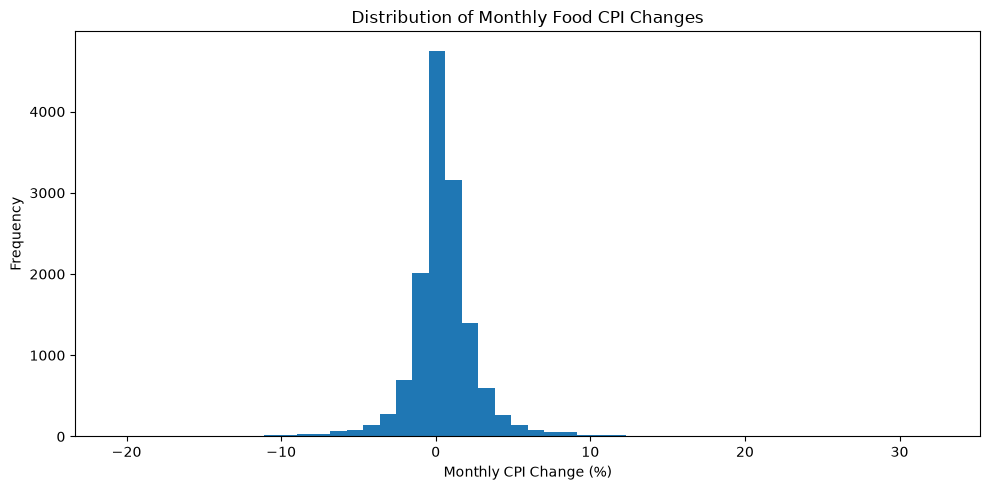

In [309]:
# EDA Question 3: how are monthly CPI changes distributed across all food items and months?
plt.figure(figsize=(10, 5))

plt.hist(
    data["CPI_Change_Pct"].dropna(),
    bins=50
)

plt.title("Distribution of Monthly Food CPI Changes")
plt.xlabel("Monthly CPI Change (%)")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

### Distribution of Monthly Food CPI Changes

The distribution of monthly CPI changes is concentrated around relatively small positive and negative changes, with the majority of observations falling within the central range of approximately -12% to 13%. The distribution also contains a small number of observations with substantially larger positive and negative changes, as identified by the minimum and maximum values.

This indicates that while most food-price movements are relatively moderate at the monthly level, certain food items and periods experience considerably larger changes. These observations are retained for further investigation rather than being removed solely because they represent extreme values.

In [310]:
# calculate number of observations that positive, negative or approximately zero
positive_changes = (data["CPI_Change_Pct"] > 0).sum()
negative_changes = (data["CPI_Change_Pct"] < 0).sum()
zero_changes = (data["CPI_Change_Pct"] == 0).sum()

print("Positive changes:", positive_changes)
print("Negative changes:", negative_changes)
print("Zero changes:", zero_changes)

Positive changes: 8463
Negative changes: 4869
Zero changes: 684


In [311]:
# percentage calculations
total_changes = data["CPI_Change_Pct"].notna().sum()
print(
    "Positive:",
    round((positive_changes / total_changes) * 100, 2),
    "%"
)

print(
    "Negative:",
    round((negative_changes / total_changes) * 100, 2),
    "%"
)

print(
    "Zero:",
    round((zero_changes / total_changes) * 100, 2),
    "%"
)

Positive: 60.38 %
Negative: 34.74 %
Zero: 4.88 %


### Calculation Analysis
Out of the 14,016 non-missing category-month CPI changes, 8,463 (60.38%) were positive, 4,869 (34.74%) were negative, and 684 (4.88%) were unchanged.

The higher frequency of positive monthly CPI changes indicates that food-price increases occur more frequently than decreases across the disaggregated observations. This descriptive pattern provides useful context for the subsequent analysis of asymmetric exchange-rate pass-through. However, the frequency of price increases alone does not establish that exchange-rate movements are responsible for these changes. 

In [312]:
# Question 4: Do different food categories behave differently?

category_volatility = (
    data.groupby("SubclassDescription")["CPI_Change_Pct"]
    .agg(["mean", "std", "min", "max"])
    .sort_values("std", ascending=False)
)

category_volatility.head(10)

,mean,std,min,max
SubclassDescription,,,,
"Fruit-bearing vegetables, fresh or chilled",0.726732,6.623252,-20.660147,31.470588
"Dates, figs and tropical fruits, fresh",0.776218,5.633144,-12.486309,20.084567
Tubers,0.638511,5.332827,-13.287402,21.302428
"Other fruits, fresh",0.124804,5.116449,-18.889809,15.410200
"Leafy or stem vegetables, fresh or chilled",0.519322,4.808853,-13.442211,32.545455
"Other vegetables, fresh or chilled",0.513281,3.781863,-16.646341,21.150442
Vegetable oils,0.580431,2.616315,-7.934132,16.046967
"Stone fruits and pome fruits, fresh",0.503984,2.456768,-8.364084,5.300000
Milk-based desserts and beverages,0.348971,2.355304,-7.002188,7.011494


### Food category Analysis 
Different food categories exhibit different degrees of monthly CPI volatility.

Volatility: how fast and how much something changes or moves up and down over time

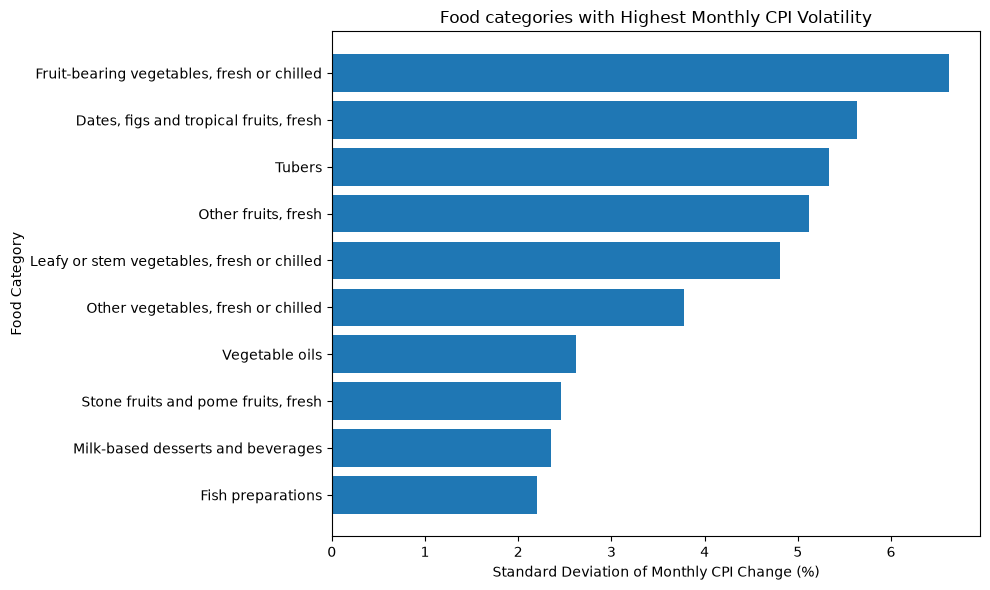

In [313]:
top_10_volatility = category_volatility.head(10)

plt.figure(figsize=(10, 6))
plt.barh(
    top_10_volatility.index[::-1],
    top_10_volatility["std"][::-1]
)

plt.title("Food categories with Highest Monthly CPI Volatility")
plt.xlabel("Standard Deviation of Monthly CPI Change (%)")
plt.ylabel("Food Category")
plt.tight_layout()
plt.show()

### Volatility Analysis
The results indicate substantial heterogeneity in monthly CPI volatility across food categories. Fruit-bearing vegetables have the highest observed standard deviation of monthly CPI changes among the categories analysed, indicating greater month-to-month variability.

In [314]:
# exchange rate pass through descriptive look

monthly_exchange["ExchangeRate_Change_Pct"] = (
    monthly_exchange["ExchangeRate"]
    .pct_change() * 100
)

In [315]:
# inspect
monthly_exchange.head(10)

,Date,ExchangeRate,ExchangeRate_Change_Pct
0,2015-07-01,12.452687,NaN
1,2015-08-01,12.914595,3.709304
2,2015-09-01,13.610852,5.391244
3,2015-10-01,13.504323,-0.782682
4,2015-11-01,14.125733,4.601568
5,2015-12-01,14.936148,5.737148
6,2016-01-01,16.389125,9.727926
7,2016-02-01,15.774610,-3.749532
8,2016-03-01,15.426575,-2.206296
9,2016-04-01,14.637630,-5.114194


In [316]:
# exchange rate movement and food-price movements
eda_relationship = data.merge(
    monthly_exchange[
        ["Date", "ExchangeRate_Change_Pct"]
    ],
    on="Date",
    how="left"
)

In [317]:
eda_relationship[
    [
        "Date",
        "SubclassDescription",
        "CPI_Change_Pct",
        "ExchangeRate_Change_Pct"
    ]
].head(15)

,Date,SubclassDescription,CPI_Change_Pct,ExchangeRate_Change_Pct
0,2015-07-01,Cereals,NaN,NaN
1,2015-08-01,Cereals,3.671329,3.709304
2,2015-09-01,Cereals,-0.674536,5.391244
3,2015-10-01,Cereals,1.018676,-0.782682
4,2015-11-01,Cereals,-1.008403,4.601568
5,2015-12-01,Cereals,-0.339559,5.737148
6,2016-01-01,Cereals,1.703578,9.727926
7,2016-02-01,Cereals,0.335008,-3.749532
8,2016-03-01,Cereals,0.500835,-2.206296
9,2016-04-01,Cereals,1.827243,-5.114194


In [318]:
# Aggregate correlation
eda_relationship[
["CPI_Change_Pct", "ExchangeRate_Change_Pct"]
].corr()

,CPI_Change_Pct,ExchangeRate_Change_Pct
CPI_Change_Pct,1.000000,0.003515
ExchangeRate_Change_Pct,0.003515,1.000000


### Correlation Analysis
The correlation between monthly USD/ZAR exchnage rate changes and monthly food CPI changes is approxiamtely zero (r = 0.0035), this indicates that there is no meaningful linear relationship between exchange rate movements and food CPI changes happening in the same month.

In [319]:
# Calculate lag correlations
lag_correlations = {
    "Simultaneous" : eda_relationship[
        ["CPI_Change_Pct", "ExchangeRate_Change_Pct"]
    ].corr().iloc[0, 1],
    
    "Lag 1": eda_relationship[
        ["CPI_Change_Pct", "ExchangeRate_Lag1"]
    ].corr().iloc[0, 1],
    
    "Lag 3": eda_relationship[
        ["CPI_Change_Pct", "ExchangeRate_Lag3"]
    ].corr().iloc[0, 1],
    
    "Lag 6": eda_relationship[
        ["CPI_Change_Pct", "ExchangeRate_Lag6"]
    ].corr().iloc[0, 1]       
}

lag_correlations

{'Simultaneous': np.float64(0.003515307060448494),
 'Lag 1': np.float64(0.012242653479107801),
 'Lag 3': np.float64(0.002705971902004899),
 'Lag 6': np.float64(-0.018657164830615726)}

### Lag Correlation Analysis

All four correlations are extremely close to zero, this indicates that there is no meaningful linear association between aggregate monthly exchange rate changes and the category level CPI changes at these particular lags.

In [320]:
# category-level correlations
category_correlations = (
    eda_relationship
    .groupby("SubclassDescription")
    .apply(
        lambda x: x["CPI_Change_Pct"]
        .corr(x["ExchangeRate_Change_Pct"])
    )
    .sort_values(ascending=False)
)

category_correlations.head(10)

SubclassDescription
Butter and other fats and oils derived from milk          0.684188
Other seafood                                             0.211971
Jams, fruit jellies, marmelades, fruit puree and paste    0.183417
Flour of cereals                                          0.134878
Coffee and coffee substitutes                             0.131649
Vegetable oils                                            0.121843
Cheese                                                    0.113262
Vegetables and pulses ground and other preparations       0.110641
Leafy or stem vegetables, fresh or chilled                0.083786
Offal, blood and other parts of slaughtered animals       0.083722
dtype: float64

In [321]:
category_correlations.tail(10)

SubclassDescription
Tubers                                                      -0.079286
Milk                                                        -0.086212
Tea and other plant products for infusion                   -0.086380
Other food products n.e.c.                                  -0.100668
Cereals                                                     -0.131875
Stone fruits and pome fruits, fresh                         -0.149099
Fish                                                        -0.179520
Sugar                                                       -0.206547
Pulses                                                      -0.206994
Vegetables, tubers, plantains and cooking bananas, frozen   -0.220655
dtype: float64

### Category-level correlations Analysis
The aggregate simultaneous correlation between monthly USD/ZAR exchange-rate changes and food CPI changes was approximately 0.0035, indicating virtually no overall linear relationship when observations are considered collectively.

However, category-level correlations reveal substantial heterogeneity across food categories. For example, butter and other fats and oils derived from milk showed a relatively strong positive correlation of 0.684, while frozen vegetables, tubers, plantains and cooking bananas showed a negative correlation of -0.221. Other categories also exhibited varying positive and negative relationships.

These differences demonstrate the importance of disaggregated analysis. An aggregate correlation may mask relationships that exist within individual food categories. However, these correlations are descriptive and do not establish causality or quantify exchange-rate pass-through.

In [322]:
# calculate category-level correlations at different lags
category_lag_correlations = pd.DataFrame({
    "Simultaneous": eda_relationship.groupby("SubclassDescription").apply(
        lambda x: x["CPI_Change_Pct"].corr(x["ExchangeRate_Change_Pct"])
    ),
    "Lag_1": eda_relationship.groupby("SubclassDescription").apply(
        lambda x: x["CPI_Change_Pct"].corr(x["ExchangeRate_Lag1"])
    ),
    "Lag_3": eda_relationship.groupby("SubclassDescription").apply(
        lambda x: x["CPI_Change_Pct"].corr(x["ExchangeRate_Lag3"])
    ),
    "Lag_6": eda_relationship.groupby("SubclassDescription").apply(
        lambda x: x["CPI_Change_Pct"].corr(x["ExchangeRate_Lag6"])
    )
})

category_lag_correlations.head()

,Simultaneous,Lag_1,Lag_3,Lag_6
SubclassDescription,,,,
Baby food,-0.030148,0.036818,0.024932,0.006429
Bread and bakery products,0.038783,0.015550,0.013020,-0.027121
Breakfast cereals,-0.016912,-0.016800,-0.009054,-0.018244
Butter and other fats and oils derived from milk,0.684188,-0.115794,0.394147,-0.147061
Cereals,-0.131875,0.098863,0.105481,-0.007632


In [323]:
print("Strongest simultaneous correlations:")
print(category_lag_correlations["Simultaneous"].sort_values(ascending=False).head(5))

print("\nStrongest 1-month lag correlations:")
print(category_lag_correlations["Lag_1"].sort_values(ascending=False).head(5))

print("\nStrongest 3-month lag correlations:")
print(category_lag_correlations["Lag_3"].sort_values(ascending=False).head(5))

print("\nStrongest 6-month lag correlations:")
print(category_lag_correlations["Lag_6"].sort_values(ascending=False).head(5))

Strongest simultaneous correlations:
SubclassDescription
Butter and other fats and oils derived from milk          0.684188
Other seafood                                             0.211971
Jams, fruit jellies, marmelades, fruit puree and paste    0.183417
Flour of cereals                                          0.134878
Coffee and coffee substitutes                             0.131649
Name: Simultaneous, dtype: float64

Strongest 1-month lag correlations:
SubclassDescription
Chocolate, cocoa, and cocoa-based food products              0.181219
Pulses                                                       0.171410
Coffee and coffee substitutes                                0.158794
Sugar                                                        0.134339
Vegetables, tubers, plantains and cooking bananas, frozen    0.131829
Name: Lag_1, dtype: float64

Strongest 3-month lag correlations:
SubclassDescription
Butter and other fats and oils derived from milk    0.394147
Coffee and coffee su

### Analysis on category-level correlations at different lags
Some categories show stronger associations with exchange-rate movements than others, and the timing of these associations varies across categories.  

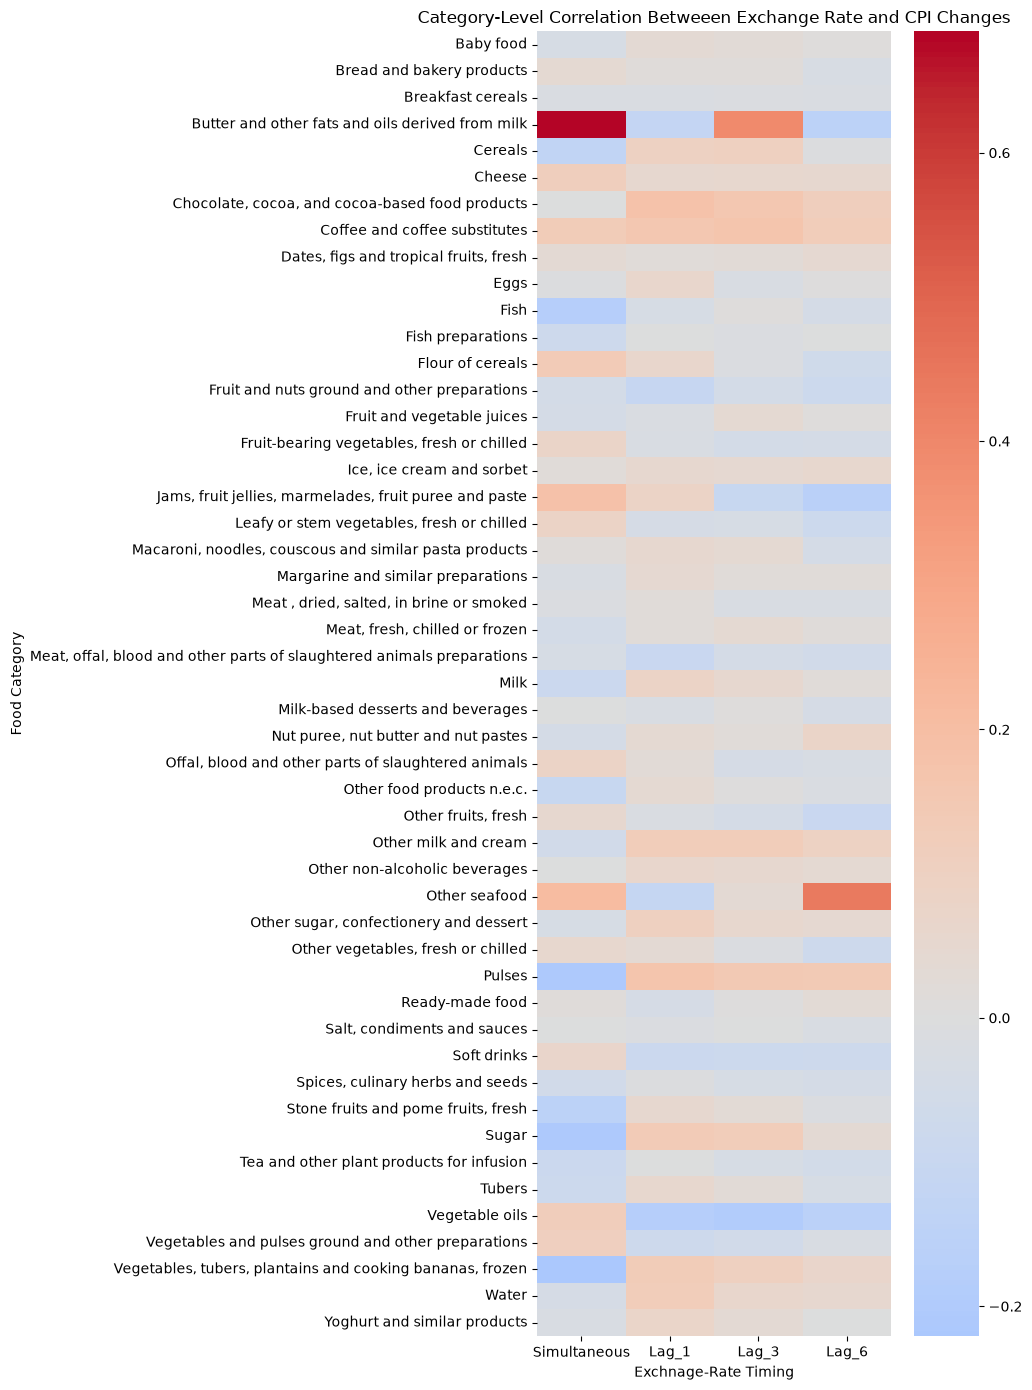

In [324]:
import seaborn as sns

plt.figure(figsize=(10,14))

sns.heatmap(
    category_lag_correlations,
    annot=False,
    cmap="coolwarm",
    center=0
)

plt.title("Category-Level Correlation Betweeen Exchange Rate and CPI Changes")
plt.xlabel("Exchnage-Rate Timing")
plt.ylabel("Food Category")

plt.tight_layout()
plt.show()

### Heatmap Analysis

The heatmap indicates substantial variation in the direction and strength of the correlation between exchange-rate changes and food CPI changes across categories and lag structures. Some categories exhibit positive associations, while others show weak negative or near-zero relationships. The variation across lags further suggests that the timing of the association may differ between food categories.

In [325]:
# Visualise selected category-level relationships
selected_categories = [
    "Butter and other fats and oils derived from milk",
    "Cereals",
    "Sugar"
]

selected_data = eda_relationship[
    eda_relationship["SubclassDescription"].isin(selected_categories)
].copy()

selected_data.head()

,Date,DivisionDescription,GroupDescription,ClassDescription,SubclassDescription,Weight,Eight digit code,CPI,ExchangeRate,Year,...,CPI_Lag1,CPI_Lag3,ExchangeRate_Change,Depreciation,Appreciation,ExchangeRate_MA3,ExchangeRate_STD3,CPI_Change,CPI_Change_Pct,ExchangeRate_Change_Pct
0,2015-07-01,Food and non-alcoholic beverages,Food,Cereal products,Cereals,0.540243,1111201,57.2,12.452687,2015,...,57.0,57.0,0.012163,0.012163,0.000000,12.241892,0.247116,NaN,NaN,NaN
1,2015-08-01,Food and non-alcoholic beverages,Food,Cereal products,Cereals,0.540243,1111201,59.3,12.914595,2015,...,57.2,57.3,0.037093,0.037093,0.000000,12.556777,0.318784,0.036713,3.671329,3.709304
2,2015-09-01,Food and non-alcoholic beverages,Food,Cereal products,Cereals,0.540243,1111201,58.9,13.610852,2015,...,59.3,57.0,0.053912,0.053912,0.000000,12.992711,0.583021,-0.006745,-0.674536,5.391244
3,2015-10-01,Food and non-alcoholic beverages,Food,Cereal products,Cereals,0.540243,1111201,59.5,13.504323,2015,...,58.9,57.2,-0.007827,0.000000,0.007827,13.343257,0.375034,0.010187,1.018676,-0.782682
4,2015-11-01,Food and non-alcoholic beverages,Food,Cereal products,Cereals,0.540243,1111201,58.9,14.125733,2015,...,59.5,59.3,0.046016,0.046016,0.000000,13.746969,0.332316,-0.010084,-1.008403,4.601568


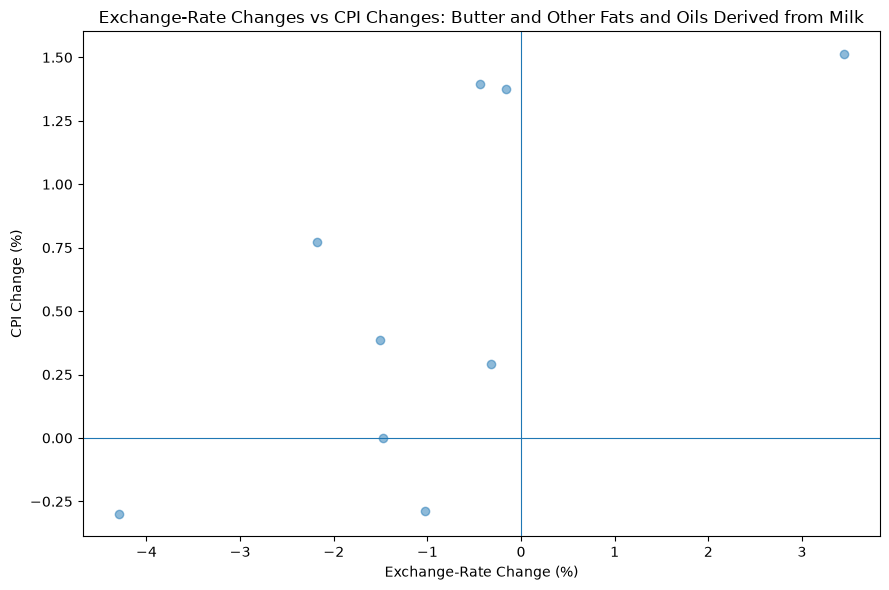

In [326]:
# Plot butter, fats and oils
butter_data = selected_data[
    selected_data["SubclassDescription"] ==
    "Butter and other fats and oils derived from milk"
]

plt.figure(figsize=(9, 6))

plt.scatter(
    butter_data["ExchangeRate_Change_Pct"],
    butter_data["CPI_Change_Pct"],
    alpha=0.5
)

plt.title(
    "Exchange-Rate Changes vs CPI Changes: "
    "Butter and Other Fats and Oils Derived from Milk"
)
plt.xlabel("Exchange-Rate Change (%)")
plt.ylabel("CPI Change (%)")

plt.axhline(0, linewidth=0.8)
plt.axvline(0, linewidth=0.8)

plt.tight_layout()
plt.show()

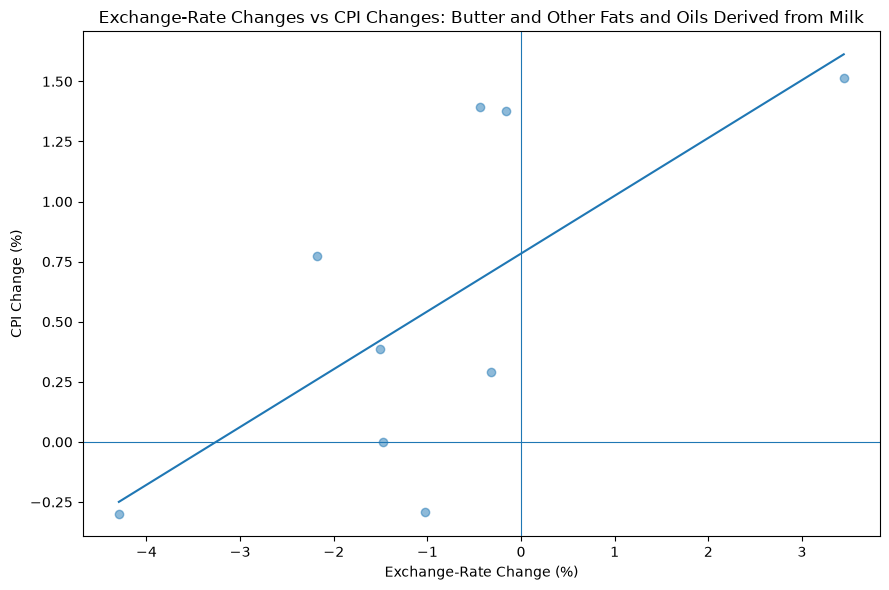

In [327]:
plt.figure(figsize=(9, 6))

plt.scatter(
    butter_data["ExchangeRate_Change_Pct"],
    butter_data["CPI_Change_Pct"],
    alpha=0.5
)

# Remove missing values
plot_data = butter_data[
    ["ExchangeRate_Change_Pct", "CPI_Change_Pct"]
].dropna()

# Calculate trend line
slope, intercept = np.polyfit(
    plot_data["ExchangeRate_Change_Pct"],
    plot_data["CPI_Change_Pct"],
    1
)

x_values = np.linspace(
    plot_data["ExchangeRate_Change_Pct"].min(),
    plot_data["ExchangeRate_Change_Pct"].max(),
    100
)

y_values = slope * x_values + intercept

plt.plot(x_values, y_values)

plt.title(
    "Exchange-Rate Changes vs CPI Changes: "
    "Butter and Other Fats and Oils Derived from Milk"
)
plt.xlabel("Exchange-Rate Change (%)")
plt.ylabel("CPI Change (%)")

plt.axhline(0, linewidth=0.8)
plt.axvline(0, linewidth=0.8)

plt.tight_layout()
plt.show()

### Scatter plot Analysis: butter, fats and oils
When the USD/ZAR exchange-rate change is higher, the CPI change for this category also tends to be higher.

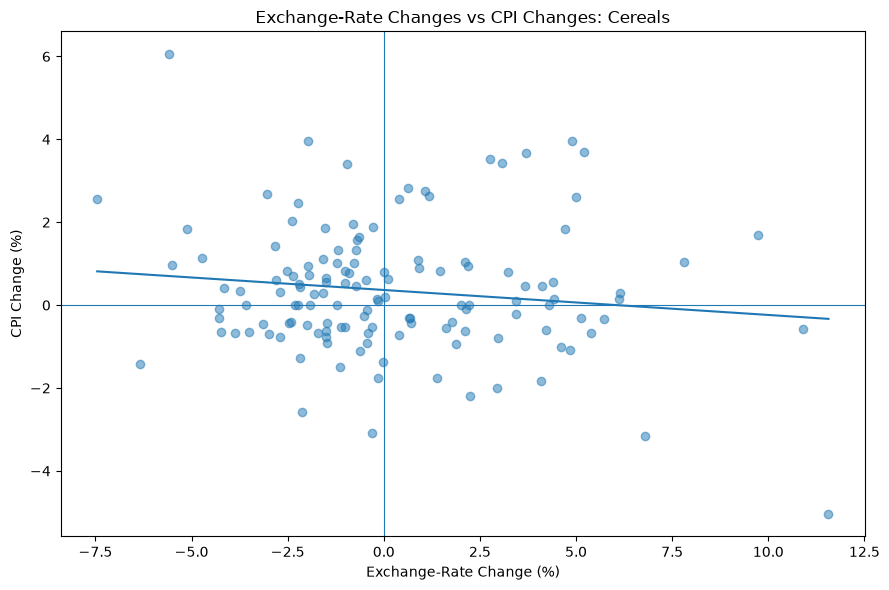

In [328]:
# Plot Cereals
cereals_data = selected_data[
    selected_data["SubclassDescription"] == "Cereals"
]

plt.figure(figsize=(9, 6))

plt.scatter(
    cereals_data["ExchangeRate_Change_Pct"],
    cereals_data["CPI_Change_Pct"],
    alpha=0.5
)

plot_data = cereals_data[
    ["ExchangeRate_Change_Pct", "CPI_Change_Pct"]
].dropna()

slope, intercept = np.polyfit(
    plot_data["ExchangeRate_Change_Pct"],
    plot_data["CPI_Change_Pct"],
    1
)

x_values = np.linspace(
    plot_data["ExchangeRate_Change_Pct"].min(),
    plot_data["ExchangeRate_Change_Pct"].max(),
    100
)

plt.plot(
    x_values,
    slope * x_values + intercept
)

plt.title("Exchange-Rate Changes vs CPI Changes: Cereals")
plt.xlabel("Exchange-Rate Change (%)")
plt.ylabel("CPI Change (%)")

plt.axhline(0, linewidth=0.8)
plt.axvline(0, linewidth=0.8)

plt.tight_layout()
plt.show()

### Scatter plot Analysis: Cereal
Exchange rate changes and CPI changes have a weak tendency to move in opposite directions.

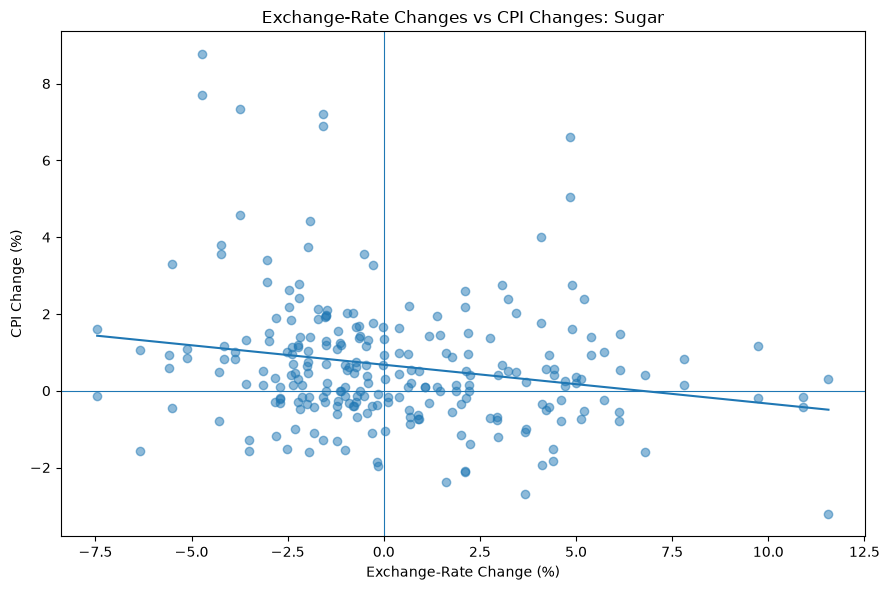

In [329]:
# Plot Sugar
sugar_data = selected_data[
    selected_data["SubclassDescription"] == "Sugar"
]

plt.figure(figsize=(9, 6))

plt.scatter(
    sugar_data["ExchangeRate_Change_Pct"],
    sugar_data["CPI_Change_Pct"],
    alpha=0.5
)

plot_data = sugar_data[
    ["ExchangeRate_Change_Pct", "CPI_Change_Pct"]
].dropna()

slope, intercept = np.polyfit(
    plot_data["ExchangeRate_Change_Pct"],
    plot_data["CPI_Change_Pct"],
    1
)

x_values = np.linspace(
    plot_data["ExchangeRate_Change_Pct"].min(),
    plot_data["ExchangeRate_Change_Pct"].max(),
    100
)

plt.plot(
    x_values,
    slope * x_values + intercept
)

plt.title("Exchange-Rate Changes vs CPI Changes: Sugar")
plt.xlabel("Exchange-Rate Change (%)")
plt.ylabel("CPI Change (%)")

plt.axhline(0, linewidth=0.8)
plt.axvline(0, linewidth=0.8)

plt.tight_layout()
plt.show()

### Visual Analysis of Category-Level Relationships

Scatter plots with linear trend lines were used to visually examine the relationship between monthly exchange-rate changes and monthly CPI changes for selected food categories.

Butter and other fats and oils derived from milk showed an upward-sloping trend line, consistent with its relatively strong positive correlation (r = 0.684). This indicates a relatively strong positive linear association between exchange-rate changes and CPI changes for this category.

In contrast, cereals showed a downward-sloping trend line, consistent with its weak negative correlation (r = -0.132). Sugar also showed a downward-sloping trend line, with a weak negative correlation (r = -0.207).

The visual analysis demonstrates that the direction and strength of the relationship between exchange-rate movements and food-price changes differ across food categories. However, these descriptive relationships do not establish causality or quantify exchange-rate pass-through.

In [330]:
# depreciation and appreciation
eda_relationship["Depreciation"] = (
    eda_relationship["ExchangeRate_Change_Pct"] > 0
).astype(int)

eda_relationship["Appreciation"] = (
    eda_relationship["ExchangeRate_Change_Pct"] < 0
).astype(int)

In [331]:
eda_relationship[
    [
        "Date",
        "ExchangeRate_Change_Pct",
        "Depreciation",
        "Appreciation"
    ]
].head(15)

,Date,ExchangeRate_Change_Pct,Depreciation,Appreciation
0,2015-07-01,NaN,0,0
1,2015-08-01,3.709304,1,0
2,2015-09-01,5.391244,1,0
3,2015-10-01,-0.782682,0,1
4,2015-11-01,4.601568,1,0
5,2015-12-01,5.737148,1,0
6,2016-01-01,9.727926,1,0
7,2016-02-01,-3.749532,0,1
8,2016-03-01,-2.206296,0,1
9,2016-04-01,-5.114194,0,1


In [332]:
# depreciation and appreciation magnitudes
eda_relationship["Depreciation_Change"] = (
    eda_relationship["ExchangeRate_Change_Pct"]
    .where(eda_relationship["ExchangeRate_Change_Pct"] > 0, 0)
)

eda_relationship["Appreciation_Change"] = (
    eda_relationship["ExchangeRate_Change_Pct"]
    .where(eda_relationship["ExchangeRate_Change_Pct"] < 0, 0)
)

In [333]:
eda_relationship[
    [
        "Date",
        "ExchangeRate_Change_Pct",
        "Depreciation_Change",
        "Appreciation_Change"
    ]
].head(15)

,Date,ExchangeRate_Change_Pct,Depreciation_Change,Appreciation_Change
0,2015-07-01,NaN,0.000000,0.000000
1,2015-08-01,3.709304,3.709304,0.000000
2,2015-09-01,5.391244,5.391244,0.000000
3,2015-10-01,-0.782682,0.000000,-0.782682
4,2015-11-01,4.601568,4.601568,0.000000
5,2015-12-01,5.737148,5.737148,0.000000
6,2016-01-01,9.727926,9.727926,0.000000
7,2016-02-01,-3.749532,0.000000,-3.749532
8,2016-03-01,-2.206296,0.000000,-2.206296
9,2016-04-01,-5.114194,0.000000,-5.114194


In [334]:
# average CPI
asymmetry_summary = (
    eda_relationship
    .groupby("SubclassDescription")
    .agg(
        Mean_CPI_During_Depreciation=(
            "CPI_Change_Pct",
            lambda x: x[
                eda_relationship.loc[x.index, "Depreciation"] == 1
            ].mean()
        ),
        Mean_CPI_During_Appreciation=(
            "CPI_Change_Pct",
            lambda x: x[
                eda_relationship.loc[x.index, "Appreciation"] == 1
            ].mean()
        )
    )
)

In [335]:
asymmetry_summary.head(10)

,Mean_CPI_During_Depreciation,Mean_CPI_During_Appreciation
SubclassDescription,,
Baby food,0.428710,0.355035
Bread and bakery products,0.531732,0.547038
Breakfast cereals,0.387295,0.417266
Butter and other fats and oils derived from milk,1.512097,0.454049
Cereals,0.342158,0.358533
Cheese,0.595012,0.477765
"Chocolate, cocoa, and cocoa-based food products",0.557831,0.684704
Coffee and coffee substitutes,0.636654,0.689595
"Dates, figs and tropical fruits, fresh",1.237371,0.425481


In [336]:
# asymmetry column
asymmetry_summary["Asymmetry_Difference"] = (
    asymmetry_summary["Mean_CPI_During_Depreciation"]
    - asymmetry_summary["Mean_CPI_During_Appreciation"]
)

In [337]:
# sort positive difference from large to small
asymmetry_summary.sort_values(
    "Asymmetry_Difference",
    ascending=False
).head(10)

,Mean_CPI_During_Depreciation,Mean_CPI_During_Appreciation,Asymmetry_Difference
SubclassDescription,,,
Butter and other fats and oils derived from milk,1.512097,0.454049,1.058048
"Dates, figs and tropical fruits, fresh",1.237371,0.425481,0.811889
"Fruit-bearing vegetables, fresh or chilled",1.137732,0.414140,0.723592
"Other vegetables, fresh or chilled",0.840230,0.270310,0.569920
"Jams, fruit jellies, marmelades, fruit puree and paste",0.841601,0.347123,0.494478
"Leafy or stem vegetables, fresh or chilled",0.680978,0.396372,0.284606
"Offal, blood and other parts of slaughtered animals",0.755195,0.519787,0.235408
Vegetables and pulses ground and other preparations,0.622953,0.407286,0.215667
Cheese,0.595012,0.477765,0.117247


In [338]:
# sort negative difference from large to small
asymmetry_summary.sort_values(
    "Asymmetry_Difference",
    ascending=True
).head(10)

,Mean_CPI_During_Depreciation,Mean_CPI_During_Appreciation,Asymmetry_Difference
SubclassDescription,,,
Tubers,0.261932,0.924923,-0.662991
Sugar,0.275747,0.928907,-0.653160
"Vegetables, tubers, plantains and cooking bananas, frozen",-0.016329,0.629343,-0.645672
Pulses,0.337193,0.787029,-0.449836
"Stone fruits and pome fruits, fresh",0.277758,0.676043,-0.398286
Tea and other plant products for infusion,0.457030,0.833418,-0.376388
Milk-based desserts and beverages,0.153745,0.497453,-0.343707
"Macaroni, noodles, couscous and similar pasta products",0.263622,0.586232,-0.322610
Other food products n.e.c.,0.352782,0.670016,-0.317234


### Analysis on Descriptive Asymmetry

Not all food categories demonstrated higher average CPI changes during Rand depreciation periods. Several categories showed negative asymmetry differences, indicating that their average CPI changes were higher during periods of Rand appreciation.

For example, tubers recorded an average CPI change of 0.262% during depreciation months and 0.925% during appreciation months, resulting in an asymmetry difference of -0.663 percentage points. Sugar showed a similar pattern, with an asymmetry difference of -0.653 percentage points. Frozen vegetables, tubers, plantains and cooking bananas recorded an asymmetry difference of -0.646 percentage points.

These findings further demonstrate the heterogeneous nature of the relationship between exchange-rate movements and food prices. The direction of the descriptive asymmetry is not uniform across food categories.

In [339]:
# compare CPI with depreciation and appreciation magnitude
depreciation_correlations = (
    eda_relationship
    .groupby("SubclassDescription")
    .apply(
        lambda x: x["CPI_Change_Pct"].corr(
            x["Depreciation_Change"]
        )
    )
    .sort_values(ascending=False)
)

appreciation_correlations = (
    eda_relationship
    .groupby("SubclassDescription")
    .apply(
        lambda x: x["CPI_Change_Pct"].corr(
            x["Appreciation_Change"]
        )
    )
    .sort_values(ascending=False)
)

In [340]:
print("Strongest depreciation relationships:")
print(depreciation_correlations.head(10))

print("\nStrongest appreciation relationships:")
print(appreciation_correlations.head(10))

Strongest depreciation relationships:
SubclassDescription
Butter and other fats and oils derived from milk          0.487621
Jams, fruit jellies, marmelades, fruit puree and paste    0.253019
Flour of cereals                                          0.168171
Vegetable oils                                            0.166433
Coffee and coffee substitutes                             0.132195
Cheese                                                    0.127616
Offal, blood and other parts of slaughtered animals       0.121875
Leafy or stem vegetables, fresh or chilled                0.117424
Other vegetables, fresh or chilled                        0.106412
Soft drinks                                               0.095759
dtype: float64

Strongest appreciation relationships:
SubclassDescription
Butter and other fats and oils derived from milk       0.627602
Other seafood                                          0.314421
Vegetables and pulses ground and other preparations    0.122478
Other 

In [341]:
eda_relationship["Depreciation_Magnitude"] = (
    eda_relationship["Depreciation_Change"].abs()
)

eda_relationship["Appreciation_Magnitude"] = (
    eda_relationship["Appreciation_Change"].abs()
)

In [342]:
depreciation_magnitude_corr = (
    eda_relationship
    .groupby("SubclassDescription")
    .apply(
        lambda x: x["CPI_Change_Pct"].corr(
            x["Depreciation_Magnitude"]
        )
    )
    .sort_values(ascending=False)
)

appreciation_magnitude_corr = (
    eda_relationship
    .groupby("SubclassDescription")
    .apply(
        lambda x: x["CPI_Change_Pct"].corr(
            x["Appreciation_Magnitude"]
        )
    )
    .sort_values(ascending=False)
)

In [343]:
print("Strongest depreciation magnitude relationships:")
print(depreciation_magnitude_corr.head(10))

print("\nStrongest appreciation magnitude relationships:")
print(appreciation_magnitude_corr.head(10))

Strongest depreciation magnitude relationships:
SubclassDescription
Butter and other fats and oils derived from milk          0.487621
Jams, fruit jellies, marmelades, fruit puree and paste    0.253019
Flour of cereals                                          0.168171
Vegetable oils                                            0.166433
Coffee and coffee substitutes                             0.132195
Cheese                                                    0.127616
Offal, blood and other parts of slaughtered animals       0.121875
Leafy or stem vegetables, fresh or chilled                0.117424
Other vegetables, fresh or chilled                        0.106412
Soft drinks                                               0.095759
dtype: float64

Strongest appreciation magnitude relationships:
SubclassDescription
Pulses                                                       0.327567
Sugar                                                        0.235233
Vegetables, tubers, plantains and cook

In [344]:
asymmetry_corr = pd.concat(
    [
        depreciation_magnitude_corr.rename(
            "Depreciation_Correlation"
        ),
        appreciation_magnitude_corr.rename(
            "Appreciation_Correlation"
        )
    ],
    axis=1
)

asymmetry_corr["Difference"] = (
    asymmetry_corr["Depreciation_Correlation"]
    - asymmetry_corr["Appreciation_Correlation"]
)

asymmetry_corr.sort_values(
    "Difference",
    ascending=False
).head(10)

,Depreciation_Correlation,Appreciation_Correlation,Difference
SubclassDescription,,,
Butter and other fats and oils derived from milk,0.487621,-0.627602,1.115222
Other seafood,0.010050,-0.314421,0.324472
"Jams, fruit jellies, marmelades, fruit puree and paste",0.253019,-0.006355,0.259373
Coffee and coffee substitutes,0.132195,-0.084213,0.216409
Flour of cereals,0.168171,-0.035305,0.203476
Vegetables and pulses ground and other preparations,0.078070,-0.122478,0.200548
Cheese,0.127616,-0.052227,0.179842
Vegetable oils,0.166433,-0.011736,0.178169
"Fruit-bearing vegetables, fresh or chilled",0.082137,-0.042340,0.124477


In [345]:
asymmetry_corr.sort_values(
    "Difference",
    ascending=True
).head(10)

,Depreciation_Correlation,Appreciation_Correlation,Difference
SubclassDescription,,,
Pulses,-0.081828,0.327567,-0.409395
Sugar,-0.141444,0.235233,-0.376677
"Vegetables, tubers, plantains and cooking bananas, frozen",-0.210042,0.160986,-0.371029
Fish,-0.163975,0.141566,-0.305540
Cereals,-0.112359,0.115645,-0.228003
"Stone fruits and pome fruits, fresh",-0.190143,0.034895,-0.225037
Other food products n.e.c.,-0.086665,0.087484,-0.174149
Tea and other plant products for infusion,-0.062433,0.093352,-0.155785
Fish preparations,-0.020345,0.128706,-0.149051


### Depreciation and Appreciation Magnitude Relationships

To further investigate potential asymmetric relationships, exchange-rate changes were separated into depreciation and appreciation magnitudes. Correlations were calculated between food CPI changes and the magnitude of exchange-rate movements for each direction.

The results indicate substantial heterogeneity across food categories. Butter and other fats and oils derived from milk showed the strongest depreciation-magnitude correlation (r = 0.488) and a negative appreciation-magnitude correlation (r = -0.628). This suggests that larger Rand depreciations were positively associated with CPI changes in this category, while larger Rand appreciations were associated with CPI changes in the opposite direction.

Other categories exhibited different patterns. Pulses showed a weak negative relationship during depreciation (r = -0.082) but a stronger positive relationship during appreciation (r = 0.328), while sugar showed correlations of -0.141 and 0.235 respectively.

Overall, the results demonstrate considerable heterogeneity in the relationship between exchange rate movements and food CPI changes across categories and exchange rate directions.

In [346]:
# inspect the final dataset
eda_relationship.shape

(14150, 29)

In [347]:
eda_relationship.columns.tolist()

['Date',
 'DivisionDescription',
 'GroupDescription',
 'ClassDescription',
 'SubclassDescription',
 'Weight',
 'Eight digit code',
 'CPI',
 'ExchangeRate',
 'Year',
 'Month',
 'Quarter',
 'ExchangeRate_Lag1',
 'ExchangeRate_Lag3',
 'ExchangeRate_Lag6',
 'CPI_Lag1',
 'CPI_Lag3',
 'ExchangeRate_Change',
 'Depreciation',
 'Appreciation',
 'ExchangeRate_MA3',
 'ExchangeRate_STD3',
 'CPI_Change',
 'CPI_Change_Pct',
 'ExchangeRate_Change_Pct',
 'Depreciation_Change',
 'Appreciation_Change',
 'Depreciation_Magnitude',
 'Appreciation_Magnitude']

In [348]:
eda_relationship.isna().sum()

Date                         0
DivisionDescription          0
GroupDescription             0
ClassDescription             0
SubclassDescription          0
Weight                       0
Eight digit code             0
CPI                          0
ExchangeRate                 0
Year                         0
Month                        0
Quarter                      0
ExchangeRate_Lag1            0
ExchangeRate_Lag3            0
ExchangeRate_Lag6            0
CPI_Lag1                     0
CPI_Lag3                     0
ExchangeRate_Change          0
Depreciation                 0
Appreciation                 0
ExchangeRate_MA3             0
ExchangeRate_STD3            0
CPI_Change                 134
CPI_Change_Pct             134
ExchangeRate_Change_Pct     95
Depreciation_Change          0
Appreciation_Change          0
Depreciation_Magnitude       0
Appreciation_Magnitude       0
dtype: int64

In [349]:
# category to observations

category_counts = (
    eda_relationship
    .groupby("SubclassDescription")
    .size()
    .sort_values()
)

category_counts

SubclassDescription
Butter and other fats and oils derived from milk                            10
Other seafood                                                               10
Jams, fruit jellies, marmelades, fruit puree and paste                      55
Eggs                                                                       126
Nut puree, nut butter and nut pastes                                       126
Other fruits, fresh                                                        126
Ice, ice cream and sorbet                                                  126
Dates, figs and tropical fruits, fresh                                     126
Stone fruits and pome fruits, fresh                                        126
Water                                                                      126
Pulses                                                                     126
Vegetables, tubers, plantains and cooking bananas, frozen                  126
Other non-alcoholic beverages   

In [350]:
category_counts.describe()

count      49.000000
mean      288.775510
std       204.253138
min        10.000000
25%       126.000000
50%       252.000000
75%       378.000000
max      1029.000000
dtype: float64

In [351]:
# ckeck duplicate category-date observations
duplicates = eda_relationship[
    eda_relationship.duplicated(
        subset=["Date", "SubclassDescription"],
        keep=False
    )
]

duplicates.shape

(12322, 29)

In [352]:
print("Number of duplicate rows:", len(duplicates))

Number of duplicate rows: 12322


In [353]:
duplicates.head(20)

,Date,DivisionDescription,GroupDescription,ClassDescription,SubclassDescription,Weight,Eight digit code,CPI,ExchangeRate,Year,...,Appreciation,ExchangeRate_MA3,ExchangeRate_STD3,CPI_Change,CPI_Change_Pct,ExchangeRate_Change_Pct,Depreciation_Change,Appreciation_Change,Depreciation_Magnitude,Appreciation_Magnitude
116,2025-03-01,Food and non-alcoholic beverages,Food,Cereal products,Cereals,0.540243,1111201,98.7,18.285360,2025,...,1,18.502465,0.219687,-0.014970,-1.497006,-1.146270,0.000000,-1.146270,0.000000,1.146270
117,2025-04-01,Food and non-alcoholic beverages,Food,Cereal products,Cereals,0.540243,1111201,98.8,18.915474,2025,...,0,18.566075,0.320623,0.001013,0.101317,3.446001,3.446001,0.000000,3.446001,0.000000
118,2025-05-01,Food and non-alcoholic beverages,Food,Cereal products,Cereals,0.540243,1111201,98.7,18.103133,2025,...,1,18.434656,0.426252,-0.001012,-0.101215,-4.294581,0.000000,-4.294581,0.000000,4.294581
119,2025-06-01,Food and non-alcoholic beverages,Food,Cereal products,Cereals,0.540243,1111201,97.8,17.836520,2025,...,1,18.285042,0.562008,-0.009119,-0.911854,-1.472747,0.000000,-1.472747,0.000000,1.472747
120,2025-07-01,Food and non-alcoholic beverages,Food,Cereal products,Cereals,0.540243,1111201,96.9,17.759252,2025,...,1,17.899635,0.180420,-0.009202,-0.920245,-0.433200,0.000000,-0.433200,0.000000,0.433200
121,2025-08-01,Food and non-alcoholic beverages,Food,Cereal products,Cereals,0.540243,1111201,95.2,17.731210,2025,...,1,17.775661,0.054539,-0.017544,-1.754386,-0.157904,0.000000,-0.157904,0.000000,0.157904
122,2025-09-01,Food and non-alcoholic beverages,Food,Cereal products,Cereals,0.540243,1111201,94.6,17.463381,2025,...,1,17.651281,0.163329,-0.006303,-0.630252,-1.510492,0.000000,-1.510492,0.000000,1.510492
123,2025-10-01,Food and non-alcoholic beverages,Food,Cereal products,Cereals,0.540243,1111201,94.1,17.285200,2025,...,1,17.493263,0.224501,-0.005285,-0.528541,-1.020312,0.000000,-1.020312,0.000000,1.020312
124,2025-11-01,Food and non-alcoholic beverages,Food,Cereal products,Cereals,0.540243,1111201,91.2,17.230220,2025,...,1,17.326267,0.121885,-0.030818,-3.081828,-0.318076,0.000000,-0.318076,0.000000,0.318076
125,2025-12-01,Food and non-alcoholic beverages,Food,Cereal products,Cereals,0.540243,1111201,91.6,16.855665,2025,...,1,17.123695,0.233743,0.004386,0.438596,-2.173826,0.000000,-2.173826,0.000000,2.173826


In [354]:
# date frequency
eda_relationship["Date"].sort_values().unique()[:10]

<DatetimeArray>
['2015-07-01 00:00:00', '2015-08-01 00:00:00', '2015-09-01 00:00:00',
 '2015-10-01 00:00:00', '2015-11-01 00:00:00', '2015-12-01 00:00:00',
 '2016-01-01 00:00:00', '2016-02-01 00:00:00', '2016-03-01 00:00:00',
 '2016-04-01 00:00:00']
Length: 10, dtype: datetime64[us]

In [355]:
eda_relationship["Date"].sort_values().unique()[-10:]

<DatetimeArray>
['2025-03-01 00:00:00', '2025-04-01 00:00:00', '2025-05-01 00:00:00',
 '2025-06-01 00:00:00', '2025-07-01 00:00:00', '2025-08-01 00:00:00',
 '2025-09-01 00:00:00', '2025-10-01 00:00:00', '2025-11-01 00:00:00',
 '2025-12-01 00:00:00']
Length: 10, dtype: datetime64[us]

In [356]:
eda_relationship["Date"].nunique()

126

In [357]:
# inspect duplicates
duplicates[
    ["Date", "SubclassDescription", "Eight digit code", "CPI"]
].head(30)

,Date,SubclassDescription,Eight digit code,CPI
116,2025-03-01,Cereals,1111201,98.7
117,2025-04-01,Cereals,1111201,98.8
118,2025-05-01,Cereals,1111201,98.7
119,2025-06-01,Cereals,1111201,97.8
120,2025-07-01,Cereals,1111201,96.9
121,2025-08-01,Cereals,1111201,95.2
122,2025-09-01,Cereals,1111201,94.6
123,2025-10-01,Cereals,1111201,94.1
124,2025-11-01,Cereals,1111201,91.2
125,2025-12-01,Cereals,1111201,91.6


In [358]:
duplicates["SubclassDescription"].value_counts().head(20)

SubclassDescription
Meat, fresh, chilled or frozen                                            1029
Bread and bakery products                                                  840
Salt, condiments and sauces                                                756
Meat, offal, blood and other parts of slaughtered animals preparations     523
Cheese                                                                     514
Other vegetables, fresh or chilled                                         514
Milk                                                                       504
Fruit-bearing vegetables, fresh or chilled                                 504
Other food products n.e.c.                                                 504
Meat , dried, salted, in brine or smoked                                   378
Fish                                                                       378
Yoghurt and similar products                                               378
Leafy or stem vegetables, fresh 

In [359]:
duplicates[
    ["Date", "SubclassDescription"]
].value_counts().head(20)

Date        SubclassDescription           
2017-04-01  Meat, fresh, chilled or frozen    9
2017-05-01  Meat, fresh, chilled or frozen    9
2017-06-01  Meat, fresh, chilled or frozen    9
2017-07-01  Meat, fresh, chilled or frozen    9
2017-08-01  Meat, fresh, chilled or frozen    9
2017-09-01  Meat, fresh, chilled or frozen    9
2017-10-01  Meat, fresh, chilled or frozen    9
2017-11-01  Meat, fresh, chilled or frozen    9
2017-12-01  Meat, fresh, chilled or frozen    9
2018-01-01  Meat, fresh, chilled or frozen    9
2018-02-01  Meat, fresh, chilled or frozen    9
2018-03-01  Meat, fresh, chilled or frozen    9
2018-04-01  Meat, fresh, chilled or frozen    9
2018-05-01  Meat, fresh, chilled or frozen    9
2018-06-01  Meat, fresh, chilled or frozen    9
2018-07-01  Meat, fresh, chilled or frozen    9
2018-08-01  Meat, fresh, chilled or frozen    9
2018-09-01  Meat, fresh, chilled or frozen    9
2018-10-01  Meat, fresh, chilled or frozen    9
2018-11-01  Meat, fresh, chilled or frozen   

In [360]:
# re-run duplicate check
duplicates_correct = eda_relationship[
    eda_relationship.duplicated(
        subset=["Date", "SubclassDescription", "Eight digit code"],
        keep=False
    )
]

print("Number of true duplicate rows:", len(duplicates_correct))

Number of true duplicate rows: 0
